# Week 2 — Transforms and Forward Kinematics

Where is the foot? · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/w02-transforms/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## One question, all week

> Given the joint angles, **where is the foot?**

That is *forward kinematics*. It sounds like bookkeeping, and it is —
but nothing above it works without it.

- Week 3 inverts it to decide joint angles from a desired foot position
- Week 4 uses that to place footsteps
- Week 12 feeds it into a policy’s observations

Today you will write it yourself and check it against MuJoCo to the last
decimal place.

------------------------------------------------------------------------

## Frames

A position is meaningless without saying *relative to what*. Robotics is
bookkeeping about frames:

- **world** — fixed to the ground
- **pelvis** — the robot’s body frame, which moves
- one frame per link, each fixed to its own piece of metal
- **foot site** — the point we actually care about

“The foot is at $(0.15, 0.12, 0.03)$” is only true in a stated frame.
Most robotics bugs are a quantity used in the wrong one.

------------------------------------------------------------------------

## A transform is a rotation and a translation

To move a point from a child frame into its parent:

$$\mathbf{p}_{\text{parent}} = R\,\mathbf{p}_{\text{child}} + \mathbf{t}$$

$R$ is a $3\times3$ rotation, $\mathbf{t}$ the origin offset. Chaining
two:

$$R_{ac} = R_{ab} R_{bc}, \qquad \mathbf{t}_{ac} = R_{ab}\mathbf{t}_{bc} + \mathbf{t}_{ab}$$

**Rotations do not commute.** $R_x R_y \neq R_y R_x$, and confusing the
order is the single most common kinematics bug.

------------------------------------------------------------------------

## Ways to write a rotation

| Representation | Numbers | Good | Bad |
|------------------|------------------|------------------|------------------|
| Rotation matrix | 9 | Composes by multiplication | 6 redundant constraints |
| **Quaternion** | 4 | Compact, no gimbal lock, interpolates | Sign ambiguity: $q$ and $-q$ are the same rotation |
| Axis–angle | 3 | Matches angular velocity | Awkward to compose |
| Euler angles | 3 | Human-readable | **Gimbal lock**; a dozen conventions |

**MuJoCo stores quaternions as `(w, x, y, z)`** — scalar first. Many
other libraries put the scalar last. Mixing the two produces rotations
that look plausible and are wrong.

------------------------------------------------------------------------

## Why `nq` exceeds `nv`, precisely

In [1]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
import mujoco

model = soc4180.load_g1()
data = soc4180.keyframe_data(model, "stand")
mujoco.mj_forward(model, data)

print(f"nq = {model.nq}   nv = {model.nv}   difference = {model.nq - model.nv}")
print(f"floating base qpos = {np.round(data.qpos[:7], 3)}")
print(f"             = 3 position + 4 quaternion")
print(f"quaternion norm = {np.linalg.norm(data.qpos[3:7]):.6f}  <- always 1")

nq = 36   nv = 35   difference = 1
floating base qpos = [0.   0.   0.79 1.   0.   0.   0.  ]
             = 3 position + 4 quaternion
quaternion norm = 1.000000  <- always 1

The quaternion has 4 numbers but only 3 freedoms, because it is
constrained to unit length. **Position and velocity live in
different-sized spaces**, which is why you cannot simply add a velocity
to `qpos`.

------------------------------------------------------------------------

## The body tree is the robot

Each body stores a fixed offset from its parent, then rotates about its
joint.

In [2]:
from soc4180 import kinematics as kin

for bid in kin.leg_chain(model, "left"):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, bid)
    jnt = model.body_jntadr[bid]
    axis = model.jnt_axis[jnt] if jnt >= 0 else None
    print(f"  {name:24s} offset={np.round(model.body_pos[bid], 4)}  axis={axis}")

  left_hip_pitch_link      offset=[ 0.      0.0645 -0.1027]  axis=[0. 1. 0.]
  left_hip_roll_link       offset=[ 0.      0.052  -0.0305]  axis=[1. 0. 0.]
  left_hip_yaw_link        offset=[ 0.025   0.     -0.1241]  axis=[0. 0. 1.]
  left_knee_link           offset=[-0.0783  0.0021 -0.1773]  axis=[0. 1. 0.]
  left_ankle_pitch_link    offset=[ 0.e+00 -1.e-04 -3.e-01]  axis=[0. 1. 0.]
  left_ankle_roll_link     offset=[ 0.      0.     -0.0176]  axis=[1. 0. 0.]

Read the axes: pitch joints turn about $y$, roll about $x$, yaw about
$z$. The hip has all three, the knee only pitch, the ankle pitch and
roll.

**Six joints, six freedoms** — enough to place the foot at an arbitrary
position *and* orientation. That is not an accident of design.

------------------------------------------------------------------------

## Forward kinematics, by hand

Walk the chain, composing as you go. For each body: apply its fixed
offset, then rotate about its joint axis — anchored at the joint, not
the origin.

In [3]:
def quat2mat(q):
    out = np.zeros(9); mujoco.mju_quat2Mat(out, np.asarray(q, float))
    return out.reshape(3, 3)

def axis_angle(axis, angle):
    q = np.zeros(4); mujoco.mju_axisAngle2Quat(q, np.asarray(axis, float), float(angle))
    return quat2mat(q)

def my_fk(model, qpos, side="left"):
    pos = qpos[:3].copy()             # start at the pelvis
    rot = quat2mat(qpos[3:7])
    for bid in kin.leg_chain(model, side):
        pos = pos + rot @ model.body_pos[bid]      # fixed offset
        rot = rot @ quat2mat(model.body_quat[bid])
        jnt = model.body_jntadr[bid]
        if jnt >= 0:
            a = model.jnt_pos[jnt]                 # the joint anchor
            Rj = axis_angle(model.jnt_axis[jnt], qpos[model.jnt_qposadr[jnt]])
            pos = pos + rot @ (a - Rj @ a)         # rotate about the anchor
            rot = rot @ Rj
    s = kin.foot_site_id(model, side)
    return pos + rot @ model.site_pos[s]

Twelve lines. That is the whole idea.

------------------------------------------------------------------------

## Check it against MuJoCo

Never trust kinematics you have not validated. Pick a non-trivial pose
so the test cannot pass by accident:

In [4]:
idx = kin.leg_qpos_indices(model, "left")
data.qpos[idx] = [-0.30, 0.10, 0.05, 0.70, -0.35, 0.02]   # nothing at zero
mujoco.mj_forward(model, data)

mine = my_fk(model, data.qpos, "left")
theirs = data.site_xpos[kin.foot_site_id(model, "left")]

print(f"my forward kinematics : {np.round(mine, 10)}")
print(f"mujoco  site_xpos     : {np.round(theirs, 10)}")
print(f"max absolute error    : {np.abs(mine - theirs).max():.2e}")

my forward kinematics : [-0.01850933  0.1535268   0.0730434 ]
mujoco  site_xpos     : [-0.01850933  0.1535268   0.0730434 ]
max absolute error    : 1.80e-16

**Agreement to machine precision.** Not “close enough” — the same
floating-point answer, because it is the same computation.

If your own version disagrees, the error is almost always one of:
forgetting the joint anchor, composing in the wrong order, or
scalar-last quaternions.

------------------------------------------------------------------------

## The workspace

Sweep the joints and see where the foot *can* go:

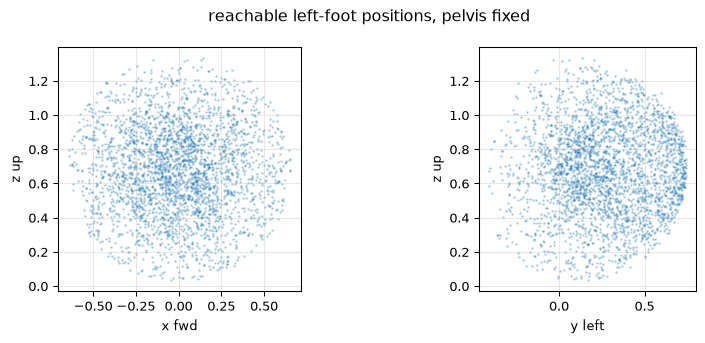

In [5]:
import matplotlib.pyplot as plt

soc4180.set_seed(4180)
lo = model.jnt_range[[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, f"left_{j}")
                      for j in kin.LEG_JOINTS], 0]
hi = model.jnt_range[[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, f"left_{j}")
                      for j in kin.LEG_JOINTS], 1]

q = data.qpos.copy()
q[:3] = [0, 0, 0.793]; q[3:7] = [1, 0, 0, 0]
pts = []
for _ in range(3000):
    q[idx] = np.random.uniform(lo, hi)
    pts.append(my_fk(model, q, "left"))
pts = np.array(pts)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].scatter(pts[:, 0], pts[:, 2], s=1, alpha=0.25); ax[0].set_xlabel("x fwd"); ax[0].set_ylabel("z up")
ax[1].scatter(pts[:, 1], pts[:, 2], s=1, alpha=0.25); ax[1].set_xlabel("y left"); ax[1].set_ylabel("z up")
for a in ax: a.set_aspect("equal"); a.grid(alpha=0.3)
fig.suptitle("reachable left-foot positions, pelvis fixed"); fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## Reading the workspace

The cloud is **not** a ball. It is bounded by joint limits, and it is
denser in the middle than at the edges — many joint combinations reach
the centre, very few reach the extremes.

Two consequences that matter later:

- A foot target near the boundary is reachable by essentially **one**
  posture, so there is no freedom left for anything else
- Near the boundary the leg is nearly straight, and small foot motions
  demand enormous joint motions

That second point is the **singularity** that dominates next week — and
it is why the Week 4 walker crouches.

------------------------------------------------------------------------

## The Jacobian, one slide early

Forward kinematics maps angles to position. Its derivative maps joint
*velocity* to foot velocity:

$$\dot{\mathbf{x}} = J(q)\,\dot{q}$$

MuJoCo computes $J$ for you, and it is the engine of next week’s IK:

In [6]:
jac_p = np.zeros((3, model.nv)); jac_r = np.zeros((3, model.nv))
mujoco.mj_jacSite(model, data, jac_p, jac_r, kin.foot_site_id(model, "left"))
J = np.vstack([jac_p, jac_r])[:, kin.leg_dof_indices(model, "left")]

print(f"leg Jacobian shape : {J.shape}   (6 foot freedoms x 6 joints)")
sv = np.linalg.svd(J, compute_uv=False)
print(f"singular values    : {np.round(sv, 4)}")
print(f"condition number   : {sv[0]/sv[-1]:.1f}")

leg Jacobian shape : (6, 6)   (6 foot freedoms x 6 joints)
singular values    : [1.8177 1.4836 1.     0.4078 0.3986 0.0886]
condition number   : 20.5

A **square** Jacobian: six joints for six freedoms. When its smallest
singular value approaches zero the leg is singular — remember that
number.

------------------------------------------------------------------------

## Exercises

1.  **Break the anchor.** Delete the `(a - Rj @ a)` term from `my_fk`
    and re-run the comparison. How large is the error, and why is it
    *zero* for some joints?
2.  **Scalar-last.** Swap the quaternion convention to $(x,y,z,w)$ in
    `quat2mat`. Does the foot end up somewhere plausible? That is what
    makes this bug nasty.
3.  **Orientation too.** Extend `my_fk` to return the foot’s rotation
    matrix and check it against `site_xmat`.
4.  **Both legs.** Compute the vector from left foot to right foot in
    the *pelvis* frame. Verify it is symmetric at the `stand` pose.
5.  **Straight-leg check.** Compute the Jacobian’s smallest singular
    value at the `stand` keyframe and at the Week 4 crouch. Which is
    closer to singular, and by how much?
6.  **Workspace volume.** Estimate the reachable volume by Monte Carlo.
    How much of it is usable if the foot must stay flat on the ground?

------------------------------------------------------------------------

## Next week

**Inverse kinematics.** Today: angles in, position out. Next: *position
in, angles out* — which is harder, sometimes has many answers, sometimes
none, and occasionally blows up entirely.